In [4]:

print("hello world")
%matplotlib widget

# %matplotlib inline

# %matplotlib qt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os, sys, pathlib, shlex, subprocess
import xbout
import scipy
import xhermes
from xhermes import *


sys.path.append(r"/users/jpm590/2dspace/post-processing/sdtools/")


from hermes3.utils import *


from hermes3.fluxes import *
from hermes3.case_db import *
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.selectors import *

%load_ext autoreload
%autoreload 2
print("Done")

hello world
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Done


## Read files

In [8]:
db = CaseDB(
    # case_dir = r"/users/jpm590/2dspace/run",
    case_dir = r"/users/jpm590/scratch/",
    grid_dir = r"/users/jpm590/neutralrun/hermes-3/master"
)

toload = [
    # dict(name="original", id="251007-2D-MASTU", unnormalise_geom = True, use_xhermes = True, squash = True)
    dict(name="wallRecyON_1e21", id="260213-cdn-46895-wallRecyON_1e21", unnormalise_geom = True, use_xhermes = True, squash = True),
    dict(name="nowallpump_1e21", id="260207-cdn-46895-nowallpump_1e21", unnormalise_geom = True, use_xhermes = True, squash = False),

]
cs = {}
for case in toload:
    cs[case["name"]] = db.load_case_2D(case["id"], use_squash = case["squash"], verbose = True)
    cs[case["name"]].extract_2d_tokamak_geometry()

/users/jpm590/workspace/hermes-3/venv/lib/python3.12/site-packages/boutdata/data.py:765: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: [Errno 2] No such file or directory: '"CDN_46895_260213_allwallpump_1e21.nc"'
Evaluating non-scalar options not available
  alwayswarn(


- Reading case 260213-cdn-46895-wallRecyON_1e21
-----------------------
- Looking for squash file
- Squash file found. squash date 02/16/2026, 14:42:56, dmp file date 02/15/2026, 13:12:16


/users/jpm590/workspace/hermes-3/venv/lib/python3.12/site-packages/xbout/load.py:1124: UserWarning: Will drop all variables containing the dimensions 'closed_wall' because they are not recognised
  warn(



Unnormalising with xHermes
- Reading case 260207-cdn-46895-nowallpump_1e21
-----------------------


/users/jpm590/workspace/hermes-3/venv/lib/python3.12/site-packages/boutdata/data.py:765: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: [Errno 2] No such file or directory: '"CDN_46895_260129_nowallpump_1e21.nc"'
Evaluating non-scalar options not available
  alwayswarn(
/users/jpm590/workspace/hermes-3/venv/lib/python3.12/site-packages/xbout/load.py:1124: UserWarning: Will drop all variables containing the dimensions 'closed_wall' because they are not recognised
  warn(



Unnormalising with xHermes


### temperature profiles

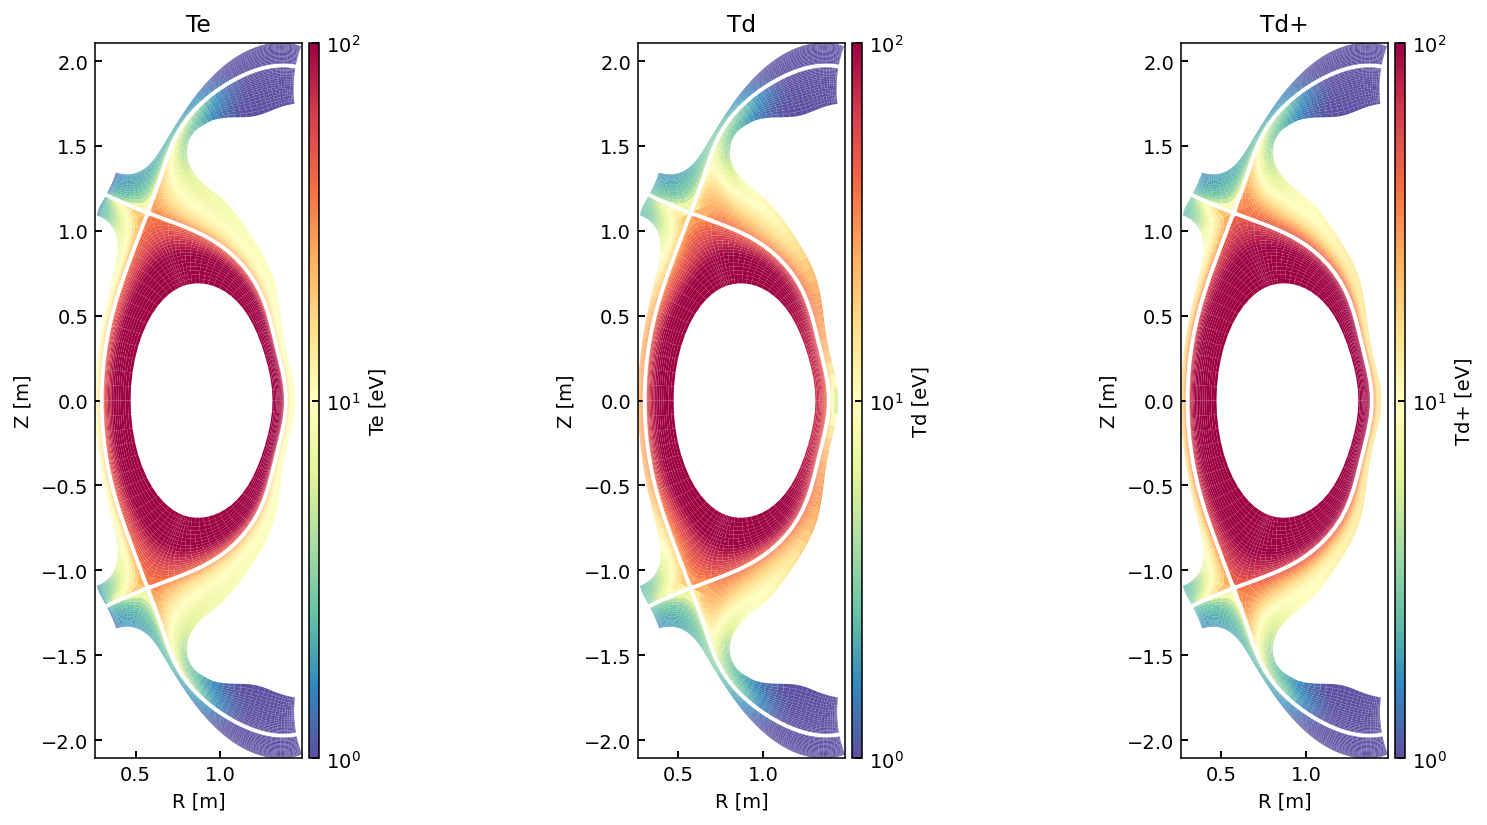

In [5]:
ds = cs["MAST-U"].ds.isel(t=-1)
fig, ax = plt.subplots(1,3 , figsize=(12,6))

ds["Te"].bout.polygon(ax = ax[0], cmap = "Spectral_r", antialias = True, logscale = True, vmin=1, vmax=100)
ds["Td"].bout.polygon(ax = ax[1], cmap = "Spectral_r", antialias = True, logscale = True, vmin=1, vmax=100)
ds["Td+"].bout.polygon(ax = ax[2], cmap = "Spectral_r", antialias = True, logscale = True, vmin=1, vmax=100)

plt.tight_layout()

### Desnity profiles

In [ ]:
ds = cs["MAST-U"].ds.isel(t=-1)
fig, ax = plt.subplots(1,3 , figsize=(12,6))

ds["Ne"].bout.polygon(ax = ax[0], cmap = "Spectral_r", antialias = True, logscale = True, )
ds["Nd"].bout.polygon(ax = ax[1], cmap = "Spectral_r", antialias = True, logscale = True, )
ds["Nd+"].bout.polygon(ax = ax[2], cmap = "Spectral_r", antialias = True, logscale = True,)

plt.tight_layout()

ValueError: 'linthresh' must be positive

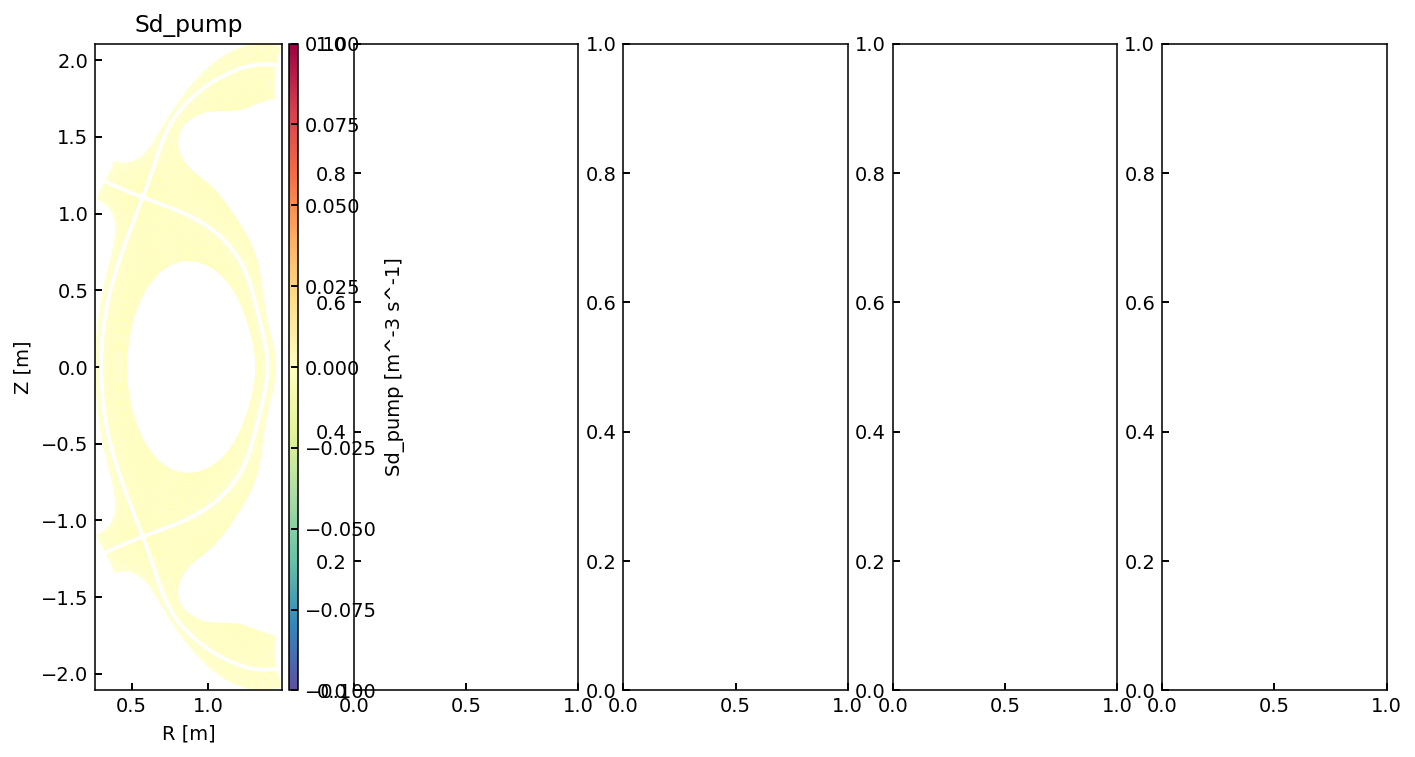

In [ ]:
ds = cs["nowallpump_1e21-U"].ds.isel(t=-1)
fig, ax = plt.subplots(1,5 , figsize=(12,6))

## Check which values <0 
if ds["Sd_target_recycle"] < 0:
    print(ds["Sd_target_recycle"])


ds["Sd_pump"].bout.polygon(ax = ax[0], cmap = "Spectral_r", antialias = True) 
# ds["Ed_target_recycle"].bout.polygon(ax = ax[1], cmap = "Spectral_r", antialias = True,logscale = True)
ds["Sd_target_recycle"].bout.polygon(ax = ax[2], cmap = "Spectral_r", antialias = True, logscale = True)
ds["Sd_src"].bout.polygon(ax = ax[3], cmap = "Spectral_r", antialias = True,logscale = True)
ds["Sd+_src"].bout.polygon(ax = ax[4], cmap = "Spectral_r", antialias = True)



plt.tight_layout()

### ddt(Desnity) profiles

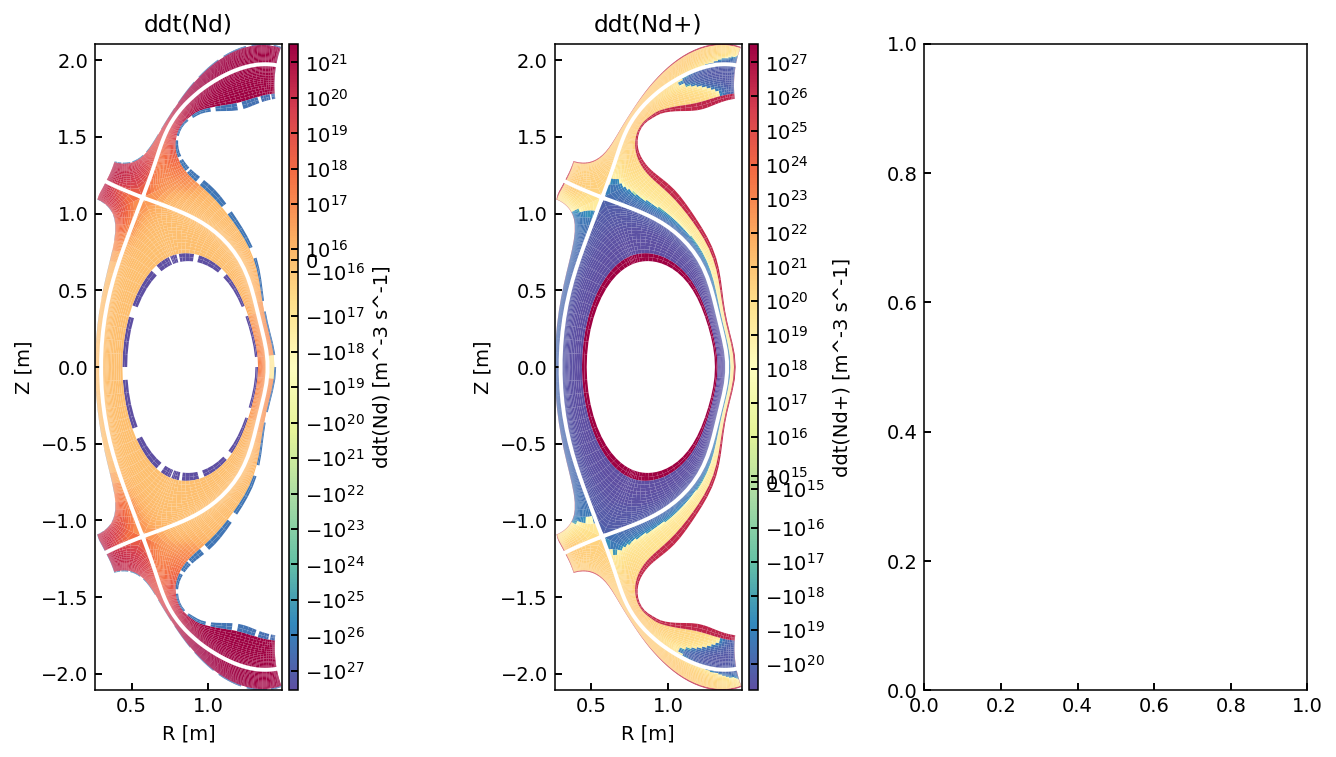

In [10]:
ds = cs["MAST-U"].ds.isel(t=-1)
fig, ax = plt.subplots(1,3 , figsize=(12,6))

ds["ddt(Nd)"].bout.polygon(ax = ax[0], cmap = "Spectral_r", antialias = True, logscale = True, )
ds["ddt(Nd+)"].bout.polygon(ax = ax[1], cmap = "Spectral_r", antialias = True, logscale = True, )

### ddt(Pressure) profiles

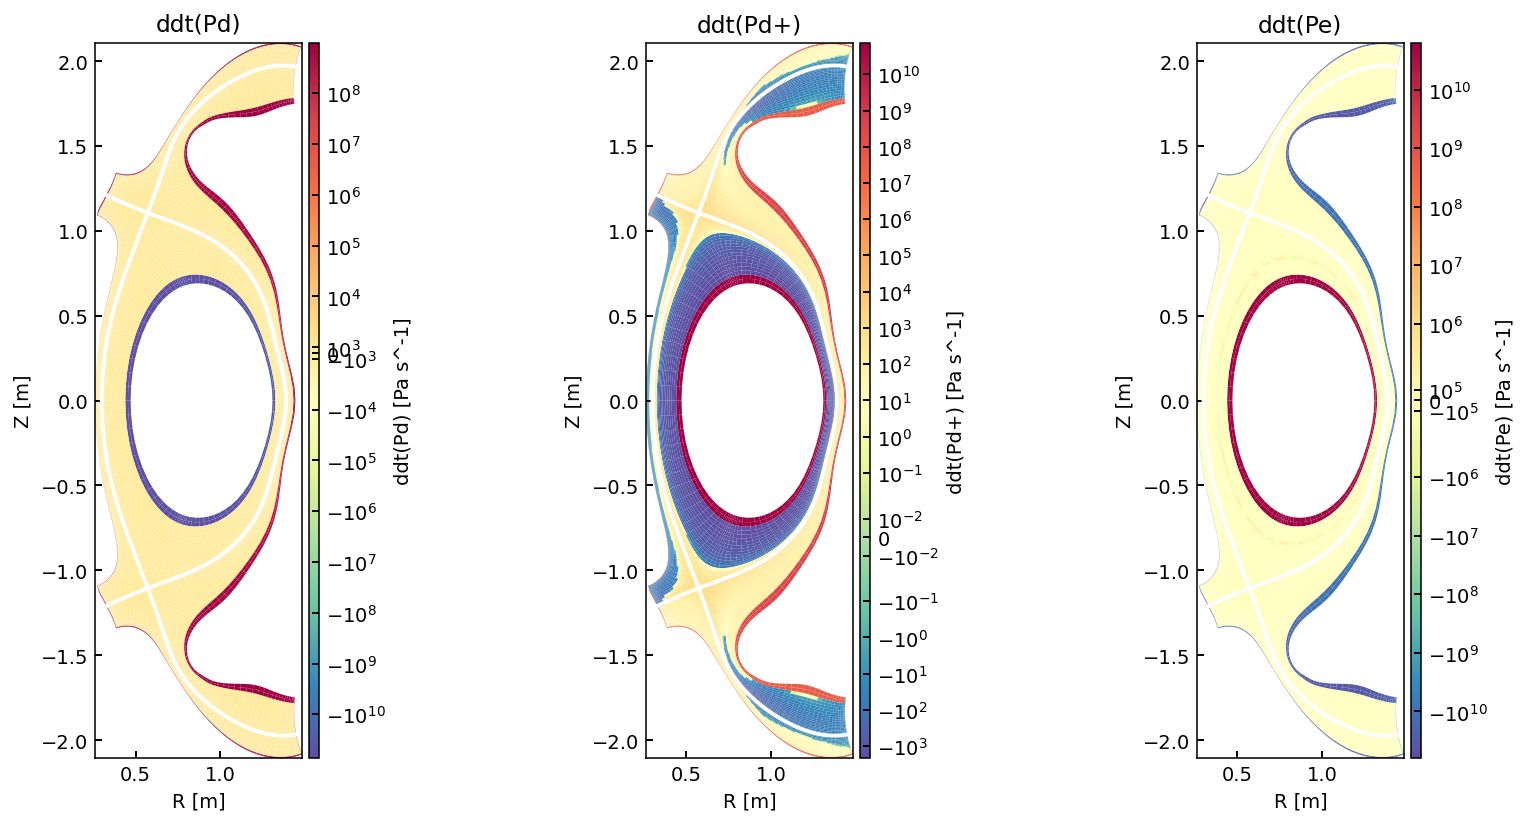

In [9]:
ds = cs["MAST-U"].ds.isel(t=-1)
fig, ax = plt.subplots(1,3 , figsize=(12,6))
ds["ddt(Pd)"].bout.polygon(ax = ax[0], cmap = "Spectral_r", antialias = True, logscale = True, )
ds["ddt(Pd+)"].bout.polygon(ax = ax[1], cmap = "Spectral_r", antialias = True, logscale = True, )
ds["ddt(Pe)"].bout.polygon(ax = ax[2], cmap = "Spectral_r", antialias = True, logscale = True, )

plt.tight_layout()

## Time evolution animation

number of frames (total number of timestep) = 100


/users/jpm590/workspace/hermes-3/venv/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


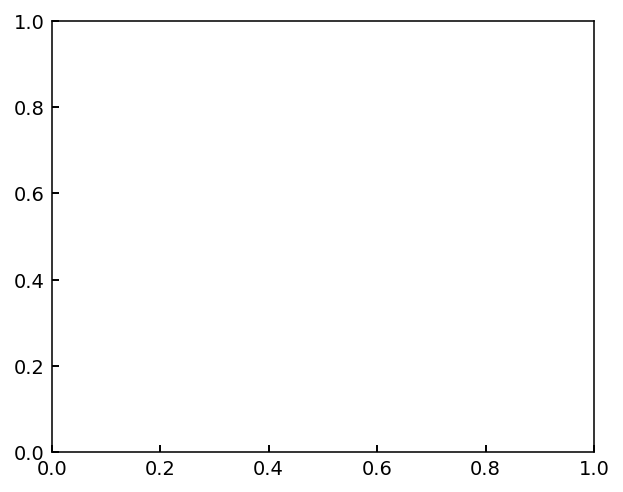

In [21]:
from matplotlib.animation import FuncAnimation

ds = cs["MAST-U"].ds

t_vals = ds.t.values
total_time = len(t_vals)
n_frames =  100 # len(t_vals)
print(f"number of frames (total number of timestep) = {n_frames}")

fig, ax = plt.subplots()


def update(frame_idx):
    
    ax.clear()
    ds_i = cs["MAST-U"].ds.isel(t=frame_idx)

    ds_i["ddt(Pd)"].bout.polygon(ax = ax, cmap = "Spectral_r", antialias = True, logscale = True, )


anim = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=200
)
# anim.save("evolution.gif", writer="pillow", dpi=150)
plt.show()